In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
import control as ct

from matplotlib import pyplot as plt
from scipy.linalg import block_diag
from sklearn.model_selection import train_test_split

import kind
import utils_data
import utils_nn

In [2]:
class linear_system:
    def __init__(self, matrix):
        self.matrix = matrix

    def __call__(self, x):
        return torch.matmul(x, torch.transpose(self.matrix, 0, 1))


### Defining a reward function

In [3]:
class quadratic_fun:
    def __init__(self, matrix):
        self.matrix = matrix

    def __call__(self, x):
        return torch.einsum('btc,cd,btd->bt', x, self.matrix, x).unsqueeze(-1)

state_ndim = 1
action_ndim = 1

state_cost = 10.0 * torch.eye(state_ndim)
action_cost = 0.01 * torch.eye(action_ndim)

reward_fun = quadratic_fun(torch.block_diag(-state_cost, -action_cost))

### Discounted return function

In [4]:
class montecarlo_fun:
    def __init__(self, discount=0.95):
        self.gamma = discount

    def __call__(self, reward):
        return torch.sum(torch.stack([self.gamma**j * r for j, r in enumerate(reward)]), dim=1, keepdim=True)

gamma = 0.88
return_fun = montecarlo_fun(gamma)

In [5]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-rl-policy-eval',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '300',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.00001',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 6, "cos": 6}',
        '--fun_trans', '{"data": 12}',
    ]
)

In [6]:
dataset = utils_data.dataset_factory().create_dataset(args)
train_loader, valid_loader, test_loader = dataset.load(data_type='stat')

In [7]:
model = kind.model(args)

model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# --! FIXME!
model._fit_dataset = dataset

In [8]:
def evaluate_policy(sa, model, args, value_fun, gamma):

    s, a, _ = torch.split(sa, 1, dim=-1) # forget mask dimension
    s = s[:, [-1]]
    a = a[:, [-1]]
    s_next = model(sa)[0][:, args.lookback_nsample:]
    s_next = s_next[:, :1]

    r = reward_fun(torch.cat([s, a], dim=-1))

    v = value_fun(s)
    v_next = value_fun(s_next)

    with torch.no_grad(): target = r + gamma * v_next

    return v, target

def validate_value(model, data_loader, args, value_fun, gamma):

    total_loss = []

    # --! set this model into evaluation mode
    value_fun.eval()

    with torch.no_grad():
        for sa, _ in data_loader:

            v, target = evaluate_policy(sa, model, args, value_fun, gamma)

            criterion = torch.nn.L1Loss()
            loss = criterion(v, target)
            total_loss.append(loss)

    # --! reset this model back to training mode
    value_fun.train()

    return np.average(total_loss)

In [9]:
value_fun_ni = 1
value_fun_no = 1
value_fun = utils_nn.fcnn(feat=[value_fun_ni, 64, 64, value_fun_no], actfun_hid='relu')

In [10]:

nepoch = 100
learning_rate = 1e-3
weight_decay = 1e-5
value_fun_optim = torch.optim.Adam(
    value_fun.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

patience = 50
checkpoints = '../../models/delay/value'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

value_fun.train()
for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:
        value_fun_optim.zero_grad()

        #max_state = torch.ones(1, state_ndim)
        #max_action = torch.ones(1, action_ndim)
        #r_max = (max_state @ state_cost @ max_state.T) + (max_action @ action_cost @ max_action.T)
        #scaling = 1 / r_max.ravel()

        v, target = evaluate_policy(sa, model, args, value_fun, gamma)
        criterion = torch.nn.L1Loss()

        loss = criterion(v, target)
        train_loss.append(loss.item())
        loss.backward()
        value_fun_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_value(model, valid_loader, args, value_fun, gamma)
    test_loss = validate_value(model, test_loader, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(value_fun, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
value_fun.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=14.595577, valid=0.955624, test=0.830249
	validation loss decreased (inf -> 0.955624), saving model ...
	epoch 2 losses: train=14.063227, valid=0.884169, test=0.762802
	validation loss decreased (0.955624 -> 0.884169), saving model ...
	epoch 3 losses: train=13.068572, valid=0.830130, test=0.716275
	validation loss decreased (0.884169 -> 0.830130), saving model ...
	epoch 4 losses: train=11.453810, valid=0.865357, test=0.774731
	early stopping counter: 1 out of 50
	epoch 5 losses: train=9.041688, valid=1.135445, test=1.116780
	early stopping counter: 2 out of 50
	epoch 6 losses: train=6.134467, valid=1.615200, test=1.654440
	early stopping counter: 3 out of 50
	epoch 7 losses: train=3.681002, valid=1.823184, test=1.876722
	early stopping counter: 4 out of 50
	epoch 8 losses: train=3.050134, valid=1.510096, test=1.539842
	early stopping counter: 5 out of 50
	epoch 9 losses: train=2.943035, valid=1.197056, test=1.198175
	early stopping counter: 6 out of 50
	epoch 1

<All keys matched successfully>

In [11]:
def improve_policy(sa, model, policy, args, value_fun, gamma):

    s_window, a_window, m_window = torch.split(sa, 1, dim=-1)
    s = s_window[:, [-1]]    
    a = policy(s)

    # --! shift a new action into action window from the right
    a_window = torch.cat([a_window[:, 1:], a], dim=1)

    # --! set mask to 1 to signalize that this is a proper action
    m_window = torch.cat([m_window[:, 1:], torch.ones_like(a)], dim=1)

    r = reward_fun(torch.cat([s, a], dim=-1))

    model_output = model(torch.cat([s_window, a_window, m_window], dim=-1))
    s_next = model_output[0][:, args.lookback_nsample:]
    s_next = s_next[:, :1]

    v_next = value_fun(s_next)

    return -torch.mean(r + gamma * v_next)

def validate_policy(policy, data_loader, model, args, value_fun, gamma):
    total_loss = []

    # --! set this model into evaluation mode
    policy.eval()

    with torch.no_grad():
        for sa, _ in data_loader:

            loss = improve_policy(sa, model, policy, args, value_fun, gamma)
            total_loss.append(loss)

    # --! reset this model back to training mode
    policy.train()

    return np.average(total_loss)

In [12]:
policy_ni = 1
policy_no = 1
policy = utils_nn.fcnn(feat=[policy_ni, 64, 64, policy_no], actfun_hid='relu')

In [13]:
nepoch = 100
learning_rate = 1e-3
weight_decay = 1e-5
policy_optim = torch.optim.Adam(
    policy.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

patience = 50
checkpoints = '../../models/delay/policy'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

policy.train()
value_fun.eval()
for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:
        policy_optim.zero_grad()

        #max_state = torch.ones(1, state_ndim)
        #max_action = torch.ones(1, action_ndim)
        #r_max = (max_state @ state_cost @ max_state.T) + (max_action @ action_cost @ max_action.T)
        #scaling = (1 - gamma) / r_max.ravel()

        loss = improve_policy(sa, model, policy, args, value_fun, gamma)

        train_loss.append(loss.item())
        loss.backward()
        policy_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_policy(policy, valid_loader, model, args, value_fun, gamma)
    test_loss = validate_policy(policy, test_loader, model, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(policy, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
policy.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=20.257101, valid=4.924926, test=4.596196
	validation loss decreased (inf -> 4.924926), saving model ...
	epoch 2 losses: train=20.228180, valid=4.955319, test=4.615279
	early stopping counter: 1 out of 50
	epoch 3 losses: train=20.261094, valid=4.950581, test=4.612276
	early stopping counter: 2 out of 50
	epoch 4 losses: train=20.302485, valid=4.965312, test=4.621391
	early stopping counter: 3 out of 50
	epoch 5 losses: train=20.257876, valid=4.971069, test=4.623658
	early stopping counter: 4 out of 50
	epoch 6 losses: train=20.233924, valid=4.972033, test=4.624210
	early stopping counter: 5 out of 50
	epoch 7 losses: train=20.244153, valid=4.970026, test=4.622688
	early stopping counter: 6 out of 50
	epoch 8 losses: train=20.218175, valid=4.971588, test=4.623795
	early stopping counter: 7 out of 50
	epoch 9 losses: train=20.223423, valid=4.973540, test=4.625225
	early stopping counter: 8 out of 50
	epoch 10 losses: train=20.253620, valid=4.979015, test=4.629284


<All keys matched successfully>

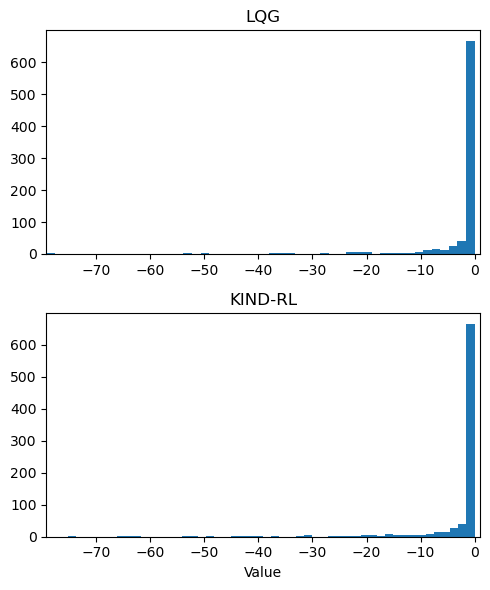

In [14]:
v_lqg = []
v_nn = []

value_fun.eval()
policy.eval()

with torch.no_grad():
    for sa, sa_next in test_loader:
        v_lqg.append(return_fun(reward_fun(sa_next[:, :, :2])))

        model_output = model(sa)
        s_next = model_output[0][:, args.lookback_nsample:]
        a_next = policy(s_next)
        sa_next = torch.cat([s_next, a_next], dim=-1)
        v_nn.append(return_fun(reward_fun(sa_next)))

    v_lqg = torch.cat(v_lqg, dim=0)
    v_nn = torch.cat(v_nn, dim=0)

    plt.figure(figsize=(5,6))
    v_min = torch.min(v_lqg)

    plt.subplot(2,1,1)
    plt.title('LQG')
    plt.hist(v_lqg.flatten(), bins=50)
    plt.xlim((v_min, 1))

    plt.subplot(2,1,2)
    plt.title('KIND-RL')
    plt.hist(v_nn.flatten(), bins=50)
    plt.xlim((v_min, 1))
    plt.xlabel('Value')

    plt.tight_layout()
    plt.show()

#plt.scatter(detuning.flatten(), control.flatten(), alpha=0.2)

In [15]:
patience = 50
checkpoints = '../../models/delay/value'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

policy.eval()
value_fun.train()

for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:

        s = sa[:, :, [0]]
        a = policy(s)
        m = torch.ones_like(a)
        sam = torch.cat([s, a, m], dim=-1)

        value_fun_optim.zero_grad()

        max_state = torch.ones(1, state_ndim)
        max_action = torch.ones(1, action_ndim)
        r_max = (max_state @ state_cost @ max_state.T) + (max_action @ action_cost @ max_action.T)
        scaling = 1 / r_max.ravel()

        v, target = evaluate_policy(sam, model, args, value_fun, gamma)
        criterion = torch.nn.L1Loss()

        loss = scaling * criterion(v, target)
        train_loss.append(loss.item())
        loss.backward()
        value_fun_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_value(model, valid_loader, args, value_fun, gamma)
    test_loss = validate_value(model, test_loader, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(value_fun, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
value_fun.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=0.276769, valid=0.717543, test=0.643189
	validation loss decreased (inf -> 0.717543), saving model ...
	epoch 2 losses: train=0.268236, valid=0.729283, test=0.644682
	early stopping counter: 1 out of 50
	epoch 3 losses: train=0.252631, valid=0.756370, test=0.661729
	early stopping counter: 2 out of 50
	epoch 4 losses: train=0.243951, valid=0.773740, test=0.674900
	early stopping counter: 3 out of 50
	epoch 5 losses: train=0.238463, valid=0.792923, test=0.688917
	early stopping counter: 4 out of 50
	epoch 6 losses: train=0.233930, valid=0.805829, test=0.698727
	early stopping counter: 5 out of 50
	epoch 7 losses: train=0.229465, valid=0.821694, test=0.711653
	early stopping counter: 6 out of 50
	epoch 8 losses: train=0.226131, valid=0.825006, test=0.713769
	early stopping counter: 7 out of 50
	epoch 9 losses: train=0.221748, valid=0.828636, test=0.715694
	early stopping counter: 8 out of 50
	epoch 10 losses: train=0.218254, valid=0.833776, test=0.719601
	early sto

<All keys matched successfully>

In [16]:
patience = 50
checkpoints = '../../models/delay/policy'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

policy.train()
value_fun.eval()

for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:
        policy_optim.zero_grad()

        max_state = torch.ones(1, state_ndim)
        max_action = torch.ones(1, action_ndim)
        r_max = (max_state @ state_cost @ max_state.T) + (max_action @ action_cost @ max_action.T)
        scaling = (1 - gamma) / r_max.ravel()

        loss = scaling * improve_policy(sa, model, policy, args, value_fun, gamma)

        train_loss.append(loss.item())
        loss.backward()
        policy_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_policy(policy, valid_loader, model, args, value_fun, gamma)
    test_loss = validate_policy(policy, test_loader, model, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(policy, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
policy.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=0.253988, valid=6.224100, test=5.999115
	validation loss decreased (inf -> 6.224100), saving model ...
	epoch 2 losses: train=0.253833, valid=6.226151, test=6.000660
	early stopping counter: 1 out of 50
	epoch 3 losses: train=0.253975, valid=6.226628, test=6.001009
	early stopping counter: 2 out of 50
	epoch 4 losses: train=0.253533, valid=6.226765, test=6.001105
	early stopping counter: 3 out of 50
	epoch 5 losses: train=0.254292, valid=6.226865, test=6.001179
	early stopping counter: 4 out of 50
	epoch 6 losses: train=0.253693, valid=6.227090, test=6.001338
	early stopping counter: 5 out of 50
	epoch 7 losses: train=0.253722, valid=6.227213, test=6.001427
	early stopping counter: 6 out of 50
	epoch 8 losses: train=0.253768, valid=6.227260, test=6.001461
	early stopping counter: 7 out of 50
	epoch 9 losses: train=0.253730, valid=6.227281, test=6.001473
	early stopping counter: 8 out of 50
	epoch 10 losses: train=0.253801, valid=6.227670, test=6.001750
	early sto

<All keys matched successfully>

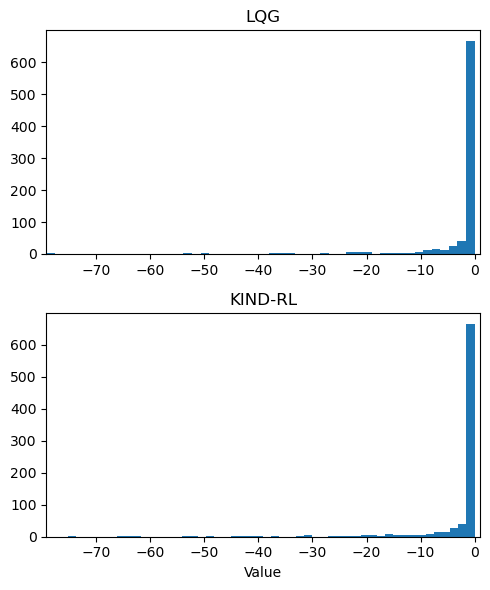

In [17]:
v_lqg = []
v_nn = []

value_fun.eval()
policy.eval()

with torch.no_grad():
    for sa, sa_next in test_loader:
        v_lqg.append(return_fun(reward_fun(sa_next[:, :, :2])))

        model_output = model(sa)
        s_next = model_output[0][:, args.lookback_nsample:]
        a_next = policy(s_next)
        sa_next = torch.cat([s_next, a_next], dim=-1)
        v_nn.append(return_fun(reward_fun(sa_next)))

    v_lqg = torch.cat(v_lqg, dim=0)
    v_nn = torch.cat(v_nn, dim=0)

    plt.figure(figsize=(5,6))
    v_min = torch.min(v_lqg)

    plt.subplot(2,1,1)
    plt.title('LQG')
    plt.hist(v_lqg.flatten(), bins=50)
    plt.xlim((v_min, 1))

    plt.subplot(2,1,2)
    plt.title('KIND-RL')
    plt.hist(v_nn.flatten(), bins=50)
    plt.xlim((v_min, 1))
    plt.xlabel('Value')

    plt.tight_layout()
    plt.show()